In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# COMPARANDO CATEGORIAS

Os gráficos deste capítulo visam ajudar nossos leitores a comparar valores entre categorias. Barras, linhas e pontos permitem que os leitores façam comparações tanto dentro de grupos quanto entre eles. Em alguns casos, queremos que o leitor visualize tanto os níveis quanto as variações, ou alguma outra combinação de variáveis; em outros, queremos concentrar sua atenção em uma comparação específica.

O desafio ao comparar dados categóricos é decidir o que queremos que o gráfico transmita. Existe um argumento ou uma narrativa principal? Há algum aspecto que possa ser identificado como a comparação mais importante que se deseja que o leitor faça? Como criadores de gráficos, precisamos priorizar a função que queremos que eles desempenhem. Ao incluir todas as barras ou pontos no gráfico, podemos acabar obscurecendo a mensagem que desejamos transmitir.

Este capítulo começa com o gráfico de barras. Assim como o gráfico de linhas que dará início ao próximo capítulo, o gráfico de barras é familiar à maioria dos leitores, o que o torna uma escolha conveniente para orientá-los ao comparar categorias ou observar mudanças ao longo do tempo. Ele também ocupa o topo do diagrama de hierarquia de percepção visual. Não é obrigatório fornecer sempre os valores exatos aos leitores, mas, quando o fazemos, o gráfico de barras é uma excelente escolha.



## GRÁFICO DE PONTOS

O gráfico de pontos (às vezes chamado de gráfico de halteres ou *dumbbell chart*) é uma das minhas alternativas favoritas aos gráficos de barras pareadas ou empilhadas. Desenvolvido por William Cleveland, um dos pioneiros na pesquisa de visualização de dados, o gráfico de pontos utiliza um símbolo — frequentemente, mas nem sempre, um círculo — correspondente ao valor do dado, conectado por uma linha ou seta. Os valores dos dados correspondem a um eixo e os grupos ao outro; não é necessário que estejam ordenados de uma maneira específica, embora a ordenação possa ajudar.

O gráfico de pontos é uma maneira simples de comparar categorias — especialmente quando há muitas delas —, evitando o excesso de tinta e a poluição visual que as barras poderiam causar na página. Para este exemplo, vamos analisar as pontuações em testes escolares ao redor do mundo provenientes do Programa Internacional de Avaliação de Alunos (PISA, um conjunto internacional de testes de desempenho realizados por estudantes de 15 anos nas áreas de leitura, matemática e ciências). Podemos facilmente representar as pontuações de matemática e leitura de um grupo de países usando um gráfico de barras simples, mas a presença de vinte barras torna o gráfico pesado e denso.

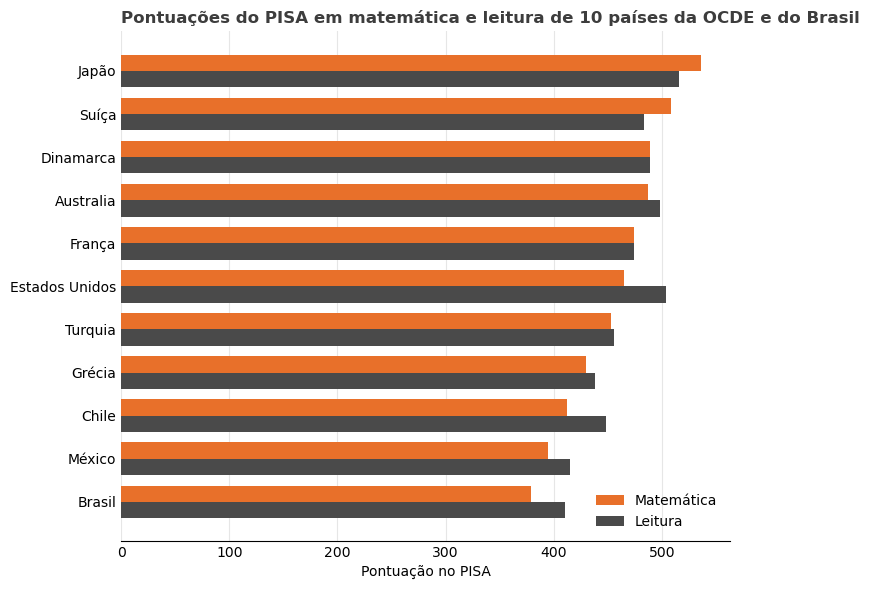

In [2]:
pisa = pd.read_csv("../Data/pisa_math_reading.csv")
pisa = pisa.sort_values("Matemática").reset_index(drop=True)

GRAFITE = "#3D3D3D"
CORES = {"Matemática": "#E8702A", "Leitura": "#4A4A4A"}

pos = np.arange(len(pisa))
altura = 0.38

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(pos + altura / 2, pisa["Matemática"], height=altura,
        label="Matemática", color=CORES["Matemática"])
ax.barh(pos - altura / 2, pisa["Leitura"], height=altura,
        label="Leitura", color=CORES["Leitura"])

ax.set_yticks(pos, pisa["País"])
ax.set_xlabel("Pontuação no PISA")
ax.set_title("Pontuações do PISA em matemática e leitura de 10 países da OCDE e do Brasil",
             loc="left", fontsize=12, color=GRAFITE, weight="bold")
ax.xaxis.grid(True, color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(length=0)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
plt.show()

Em contrapartida, o gráfico de pontos (*dot plot*) apresenta os mesmos dados com um ponto em cada valor, conectados por uma linha para indicar a amplitude ou a diferença. Os círculos consomem menos tinta do que as barras, tornando o visual mais leve graças ao maior espaço vazio. Os rótulos dos países são posicionados próximos ao ponto mais à esquerda, embora também possam ser dispostos à esquerda, ao longo do eixo vertical. Se necessário, os valores dos dados podem ser colocados ao lado, acima ou dentro de cada círculo.